In [ ]:

import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
scene = trimesh.load('../generated/for_slides.glb')

geometry_names = list(scene.geometry.keys())

print (f'Num geometries: {len(geometry_names)}')

Num geometries: 28


In [3]:
# target_tile_name = geometry_names[20]
# tile_mesh = scene.geometry[target_tile_name]

# mesh = pyrender.Mesh.from_trimesh(tile_mesh)

In [ ]:
def look_at(eye, target, up):
    """Computes the 4x4 camera pose matrix."""
    zaxis = (eye - target)
    zaxis /= np.linalg.norm(zaxis)
    xaxis = np.cross(up, zaxis)
    xaxis /= np.linalg.norm(xaxis)
    yaxis = np.cross(zaxis, xaxis)

    view_matrix = np.eye(4)
    view_matrix[:3, 0] = xaxis
    view_matrix[:3, 1] = yaxis
    view_matrix[:3, 2] = zaxis
    view_matrix[:3, 3] = eye
    return view_matrix

In [7]:
target_tile_names = geometry_names
render_scene = pyrender.Scene(bg_color=[255, 255, 255, 255], ambient_light=np.ones(4, dtype='uint8') * 200)

# 1. Collect all trimesh objects in a list
meshes = [scene.geometry[name] for name in target_tile_names]
# 2. Combine them into one single trimesh

combined_trimesh = trimesh.util.concatenate(meshes)

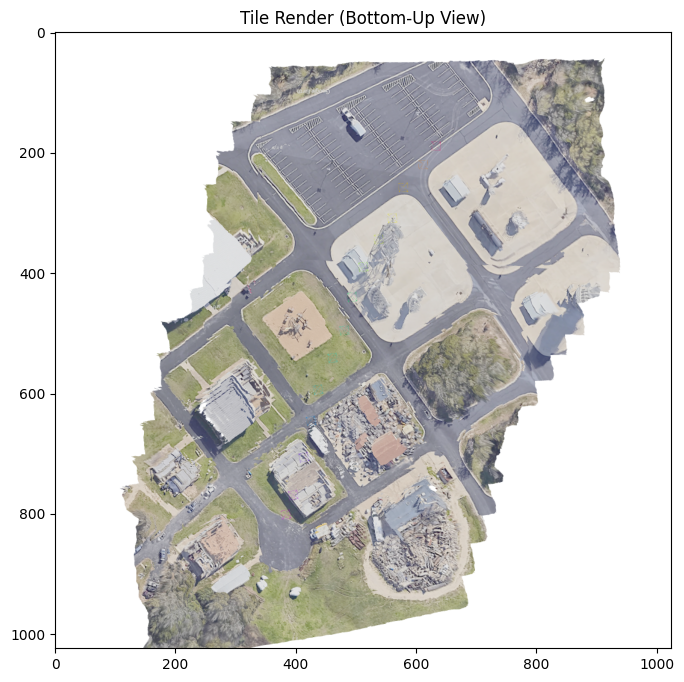

In [8]:

# 1. Setup Scene
scene_to_render = pyrender.Scene(bg_color=[255, 255, 255, 255], ambient_light=np.ones(4, dtype='uint8') * 200)
render_mesh = pyrender.Mesh.from_trimesh(combined_trimesh)
scene_to_render.add(render_mesh)

# 2. Position Camera BELOW the mesh (Z=0 is below the 21-25 range)
center = combined_trimesh.centroid
eye = np.array([center[0], center[1], 0.0]) 
target = center
# When looking UP from the bottom, we define 'Up' as the Y-axis
up = np.array([0, 1, 0]) 

camera_pose = look_at(eye, target, up)

# 3. Camera Settings
# Using the extents to ensure the whole tile fits
mag = max(combined_trimesh.extents[:2]) / 2.0
camera = pyrender.OrthographicCamera(xmag=mag, ymag=mag, znear=0.01, zfar=100.0)
scene_to_render.add(camera, pose=camera_pose)

# 4. Add Light (Crucial: Light must hit the side the camera sees)
# light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=2.0)
# scene.add(light, pose=camera_pose)

# 5. Render
r = pyrender.OffscreenRenderer(1024, 1024)
color, depth = r.render(scene_to_render)

plt.figure(figsize=(8, 8))
plt.imshow(color)
plt.title("Tile Render (Bottom-Up View)")
plt.show()

In [9]:
from PIL import Image

Image.fromarray(color).save('to_match.png')